In [1]:
!pip install seaborn scikit-learn
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
import re

In [2]:
np.random.seed(42)
neighborhoods = ['Lower Parel', 'Mahalakshmi', 'Matunga', 'Dadar', 'Tardeo', 'Byculla']
base_prices = {'Lower Parel': 4.5, 'Mahalakshmi': 5.0, 'Matunga': 3.5, 'Dadar': 3.0, 'Tardeo': 4.8, 'Byculla': 2.5}

data = {
    'Neighborhood': np.random.choice(neighborhoods, 3000),
    'Area_sqft': np.random.randint(600, 4000, 3000),
    'Bedrooms': np.random.randint(1, 6, 3000),
    'Age_Years': np.random.randint(0, 35, 3000)
}
df = pd.DataFrame(data)

def calculate_price(row):
    base = base_prices[row['Neighborhood']]
    area_factor = (row['Area_sqft'] / 1000) * 1.5
    bed_factor = row['Bedrooms'] * 0.4
    age_discount = row['Age_Years'] * 0.03
    noise = np.random.normal(0, 0.4)
    return round(base + area_factor + bed_factor - age_discount + noise, 2)

df['Price_Cr'] = df.apply(calculate_price, axis=1)
df = df[df['Price_Cr'] > 0.5]

C:\Users\tanis\AppData\Local\Temp\ipykernel_12356\1790604338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='Price_Cr', data=df, palette='Set2')


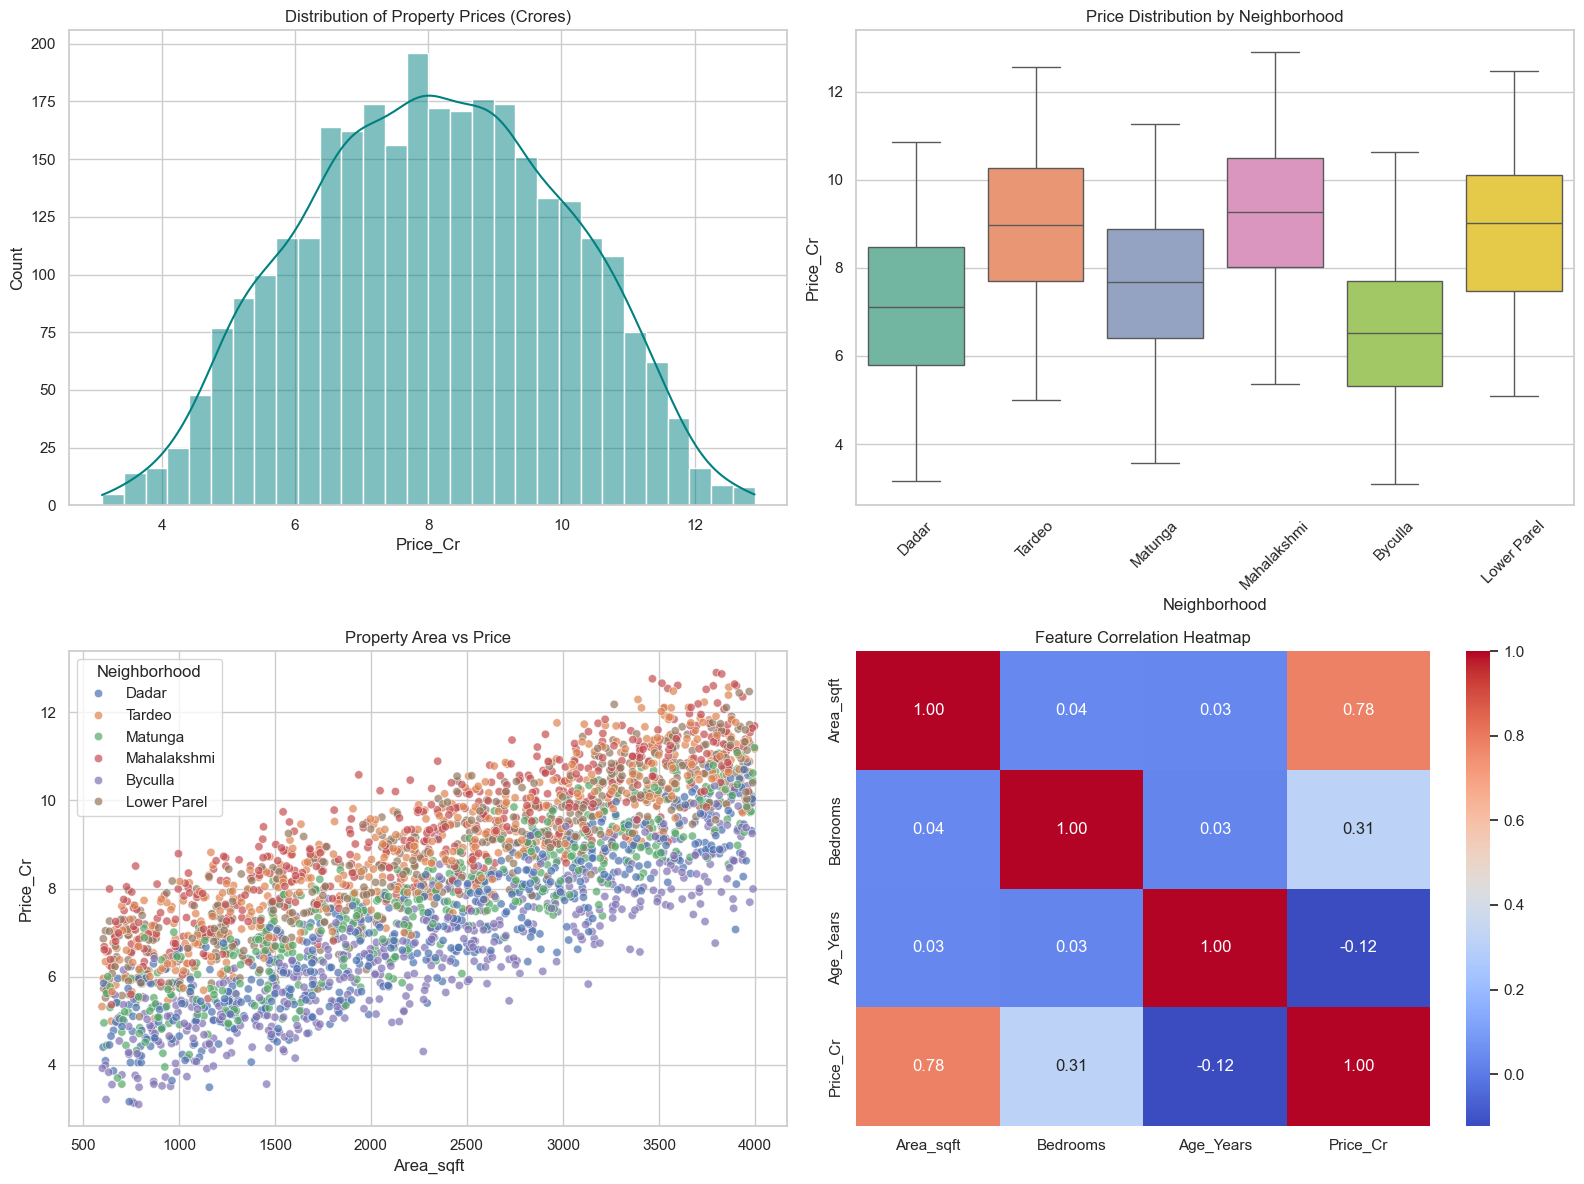

In [3]:
plt.figure(figsize=(16, 12))
sns.set_theme(style="whitegrid")

plt.subplot(2, 2, 1)
sns.histplot(df['Price_Cr'], kde=True, color='teal', bins=30)
plt.title('Distribution of Property Prices (Crores)')

plt.subplot(2, 2, 2)
sns.boxplot(x='Neighborhood', y='Price_Cr', data=df, palette='Set2')
plt.title('Price Distribution by Neighborhood')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.scatterplot(x='Area_sqft', y='Price_Cr', hue='Neighborhood', data=df, alpha=0.7, palette='deep')
plt.title('Property Area vs Price')

plt.subplot(2, 2, 4)
correlation = df[['Area_sqft', 'Bedrooms', 'Age_Years', 'Price_Cr']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [4]:
le = LabelEncoder()
df['Neighborhood_Encoded'] = le.fit_transform(df['Neighborhood'])
X = df[['Neighborhood_Encoded', 'Area_sqft', 'Bedrooms', 'Age_Years']]
y = df['Price_Cr']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=150, validation_split=0.2, callbacks=[early_stop], verbose=0)

C:\Users\tanis\Desktop\Python\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


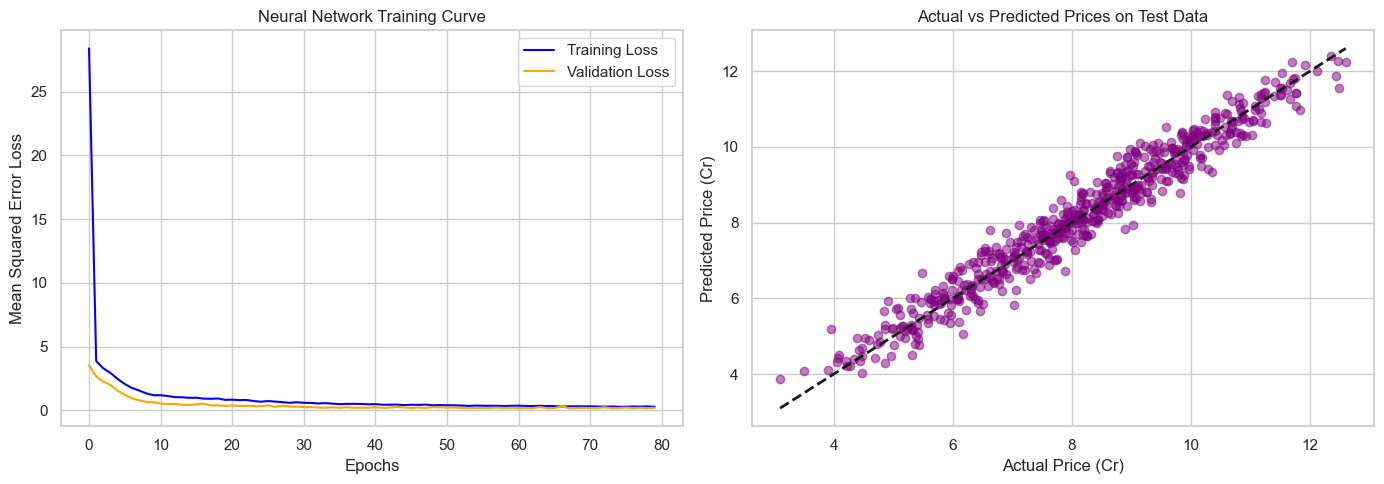

Final Model Mean Absolute Error: 0.33 Crores


In [5]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Neural Network Training Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()

plt.subplot(1, 2, 2)
y_pred = model.predict(X_test, verbose=0)
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Prices on Test Data')
plt.xlabel('Actual Price (Cr)')
plt.ylabel('Predicted Price (Cr)')

plt.tight_layout()
plt.show()

loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Model Mean Absolute Error: {mae:.2f} Crores")

🤖 AI Mumbai Real Estate Valuation Chatbot Active
Example query: 'I want a 3 bhk in Mahalakshmi of 1800 sqft that is 2 years old'
Type 'exit' or 'quit' to end the session.



You:  I want a 3 bhk in Mahalakshmi of 1800 sqft that is 2 years old


🤖 PropBot: Valuing a 3 BHK in Mahalakshmi (1800 sqft, 2 yrs old)...
📈 Estimated Market Price: ₹8.86 Crores



C:\Users\tanis\Desktop\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


You:  i want a 2 BHK in Lower Parel


...

You:  I want a 2 BHK in Lower Parel of 1000 sqft is 1 year old


🤖 PropBot: Valuing a 2 BHK in Lower Parel (1000 sqft, 1 yrs old)...
📈 Estimated Market Price: ₹6.58 Crores



C:\Users\tanis\Desktop\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


You:  exit


🤖 PropBot: Session terminated. Good luck with your investments!
